In [1]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML Libraries
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Explainability
import shap

# Experiment Tracking
import mlflow
import mlflow.sklearn

# Save Model
import joblib

In [8]:
# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv("../data/flights.csv")

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print(df.head())
print("\nDataset Shape:", df.shape)

# =========================================================
# FEATURE ENGINEERING
# =========================================================

print("\nPerforming Feature Engineering...")

# Convert Date Column
df['date'] = pd.to_datetime(df['date'])

# Extract Date Features
df['year'] = df['date'].dt.year

df['month'] = df['date'].dt.month

df['day'] = df['date'].dt.day

df['weekday'] = df['date'].dt.weekday

# Weekend Feature
df['is_weekend'] = df['weekday'].apply(
    lambda x: 1 if x >= 5 else 0
)

# Peak Travel Month
df['is_peak_month'] = df['month'].apply(
    lambda x: 1 if x in [6, 7, 12] else 0

)

# Duration Category
df['duration_category'] = pd.cut(
    df['time'],
    bins=[0, 2, 5, 10, 20],
    labels=['short', 'medium', 'long', 'very_long']
)

# Route Feature
# Drop Original Date Column
# Remove Date Column If Still Present
if 'date' in df.columns:
    df.drop('date', axis=1, inplace=True)

# Features & Target
X = df.drop("price", axis=1)

y = df["price"]

print("\nFinal Columns Used For Training:")
print(X.columns)

DATASET INFORMATION
   travelCode  userCode                from                  to  flightType  \
0           0         0         Recife (PE)  Florianopolis (SC)  firstClass   
1           0         0  Florianopolis (SC)         Recife (PE)  firstClass   
2           1         0       Brasilia (DF)  Florianopolis (SC)  firstClass   
3           1         0  Florianopolis (SC)       Brasilia (DF)  firstClass   
4           2         0        Aracaju (SE)       Salvador (BH)  firstClass   

     price  time  distance       agency        date  
0  1434.38  1.76    676.53  FlyingDrops  09/26/2019  
1  1292.29  1.76    676.53  FlyingDrops  09/30/2019  
2  1487.52  1.66    637.56      CloudFy  10/03/2019  
3  1127.36  1.66    637.56      CloudFy  10/04/2019  
4  1684.05  2.16    830.86      CloudFy  10/10/2019  

Dataset Shape: (271888, 10)

Performing Feature Engineering...

Final Columns Used For Training:
Index(['travelCode', 'userCode', 'from', 'to', 'flightType', 'time',
       'distan

In [9]:
# =========================================================
# FEATURES & TARGET
# =========================================================

X = df.drop("price", axis=1)
y = df["price"]

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

# =========================================================
# PREPROCESSING
# =========================================================

categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=['object', 'category']
).columns.tolist()

# Numerical Pipeline
numerical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical Pipeline
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Full Preprocessor
preprocessor = ColumnTransformer([
    ("num", numerical_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])


Training Shape: (217510, 15)
Testing Shape: (54378, 15)


In [10]:
# =========================================================
# RANDOM FOREST MODEL
# =========================================================

rf_model = RandomForestRegressor(
    random_state=42
)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", rf_model)
])

# Hyperparameter Grid
rf_params = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [10, 15],
    'model__min_samples_split': [2, 5]
}

print("\nStarting Random Forest Hyperparameter Tuning...")

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

print("\nBest Random Forest Parameters:")
print(rf_grid.best_params_)


Starting Random Forest Hyperparameter Tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Random Forest Parameters:
{'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [11]:
# =========================================================
# XGBOOST MODEL
# =========================================================

xgb_model = XGBRegressor(
    random_state=42
)

xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", xgb_model)
])

# Hyperparameter Grid
xgb_params = {
    'model__n_estimators': [200, 300],
    'model__learning_rate': [0.05, 0.1],
    'model__max_depth': [5, 8]
}

print("\nStarting XGBoost Hyperparameter Tuning...")

xgb_grid = GridSearchCV(
    xgb_pipeline,
    xgb_params,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

print("\nBest XGBoost Parameters:")
print(xgb_grid.best_params_)


Starting XGBoost Hyperparameter Tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best XGBoost Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 8, 'model__n_estimators': 300}


In [12]:
# =========================================================
# MODEL COMPARISON
# =========================================================

models = {
    "Random Forest": rf_grid.best_estimator_,
    "XGBoost": xgb_grid.best_estimator_
}

results = []

best_model = None
best_r2 = -999

mlflow.set_experiment(
    "Advanced Flight Price Prediction"
)

# =========================================================
# EVALUATION LOOP
# =========================================================

for model_name, model in models.items():

    print("\n" + "=" * 60)
    print(f"MODEL: {model_name}")
    print("=" * 60)

    with mlflow.start_run(run_name=model_name):

        # Predict
        y_pred = model.predict(X_test)

        # Metrics
        mae = mean_absolute_error(y_test, y_pred)

        mse = mean_squared_error(y_test, y_pred)

        rmse = np.sqrt(mse)

        r2 = r2_score(y_test, y_pred)

        # Cross Validation
        cv_scores = cross_val_score(
            model,
            X,
            y,
            cv=5,
            scoring='r2'
        )

        cv_mean = cv_scores.mean()

        # Save Results
        results.append({
            "Model": model_name,
            "MAE": round(mae, 2),
            "MSE": round(mse, 2),
            "RMSE": round(rmse, 2),
            "R2 Score": round(r2, 4),
            "CV R2 Mean": round(cv_mean, 4)
        })

        print(f"MAE: {mae:.2f}")
        print(f"RMSE: {rmse:.2f}")
        print(f"R2 Score: {r2:.4f}")

        # MLflow Logging
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)

        mlflow.sklearn.log_model(
            model,
            artifact_path=model_name.replace(" ", "_")
        )

        # Best Model Selection
        if r2 > best_r2:
            best_r2 = r2
            best_model = model
            best_model_name = model_name

# =========================================================
# RESULTS TABLE
# =========================================================

results_df = pd.DataFrame(results)

print("\nFINAL MODEL COMPARISON")
print(results_df)

# =========================================================
# SAVE BEST MODEL
# =========================================================

joblib.dump(
    best_model,
    "../models/advanced_flight_price_model.pkl"
)

print("\nBest Model Saved Successfully!")
print(f"Best Model: {best_model_name}")

2026/05/19 16:05:40 INFO mlflow.tracking.fluent: Experiment with name 'Advanced Flight Price Prediction' does not exist. Creating a new experiment.



MODEL: Random Forest


2026/05/19 16:31:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MAE: 0.86
RMSE: 3.79
R2 Score: 0.9999


2026/05/19 16:31:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



MODEL: XGBoost


2026/05/19 16:32:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MAE: 0.03
RMSE: 0.08
R2 Score: 1.0000


2026/05/19 16:32:12 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



FINAL MODEL COMPARISON
           Model   MAE    MSE  RMSE  R2 Score  CV R2 Mean
0  Random Forest  0.86  14.35  3.79    0.9999      0.9997
1        XGBoost  0.03   0.01  0.08    1.0000      1.0000

Best Model Saved Successfully!
Best Model: XGBoost


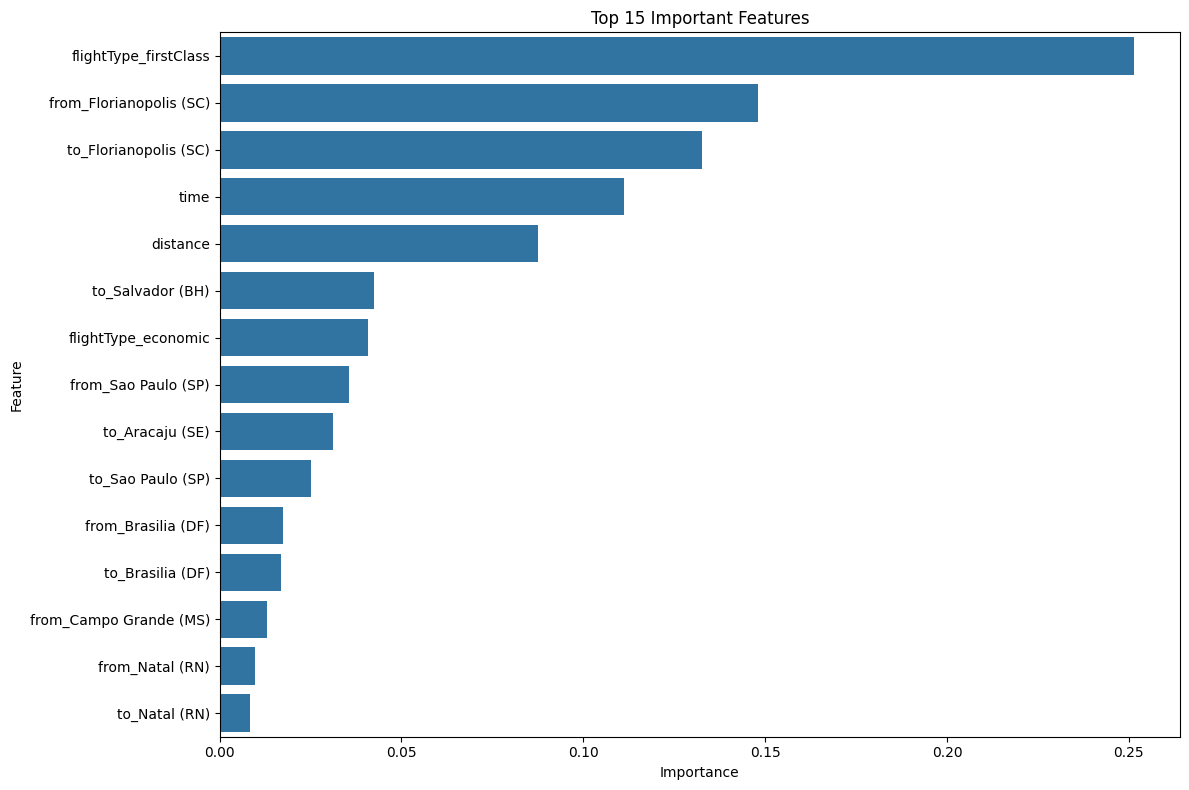

In [26]:
# =========================================================
# FEATURE IMPORTANCE
# =========================================================

try:

    model_step = best_model.named_steps['model']

    preprocessor_step = best_model.named_steps['preprocessor']

    encoded_cat_features = preprocessor_step \
        .named_transformers_['cat'] \
        .named_steps['encoder'] \
        .get_feature_names_out(categorical_features)

    all_features = np.concatenate([
        numerical_features,
        encoded_cat_features
    ])

    importances = model_step.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": all_features,
        "Importance": importances
    })

    feature_importance_df = feature_importance_df.sort_values(
        by="Importance",
        ascending=False
    ).head(15)

    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=feature_importance_df,
        x="Importance",
        y="Feature"
    )

    plt.title("Top 15 Important Features")

    plt.tight_layout()

    plt.show()

except Exception as e:

    print("Feature Importance Error:", e)

